In [29]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Math, HTML
import json
import ast
from pathlib import Path
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import logsumexp
from tqdm.auto import tqdm
outputs_path = Path("..") / "outputs"

# Data extraction and formating

In [30]:
# This file is generated from Notebook 02. It contains the probabilities from the Machine Learning Model
eod_data = pd.read_csv("../outputs/eod_probabilidades_individuales.csv")
# This file is generated from Notebook 03. It contains the estimated proportions from the entropy algorithm
agebs_data = pd.read_csv("../outputs/dwelling_types_per_ageb.csv")

for name, data in [("Dwellings from OD survey", eod_data), ("Dwellings per AGEB from 2020 Census", agebs_data)]:
    display(Markdown(f"### {name}\n\n **Rows:** {len(data):,}\n\n**Columns:** {', '.join(data.columns)}\n\n{data.head(4).to_markdown(index=False)}"))

### Dwellings from OD survey

 **Rows:** 17,901

**Columns:** folio_vivienda, ponderador, municipio, ageb, centralidad, probabilidad_tipo_vivienda, muestreo_tipo_vivienda, fuente_tipo_vivienda

|   folio_vivienda |   ponderador | municipio   | ageb          | centralidad   | probabilidad_tipo_vivienda                                                                                                                              | muestreo_tipo_vivienda   | fuente_tipo_vivienda               |
|-----------------:|-------------:|:------------|:--------------|:--------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------|:-----------------------------------|
|                1 |           51 | tlajomulco  | 1409700251418 | 30F           | {"casa_unica":0.9488597199817904,"casa_compartida_duplex":0.03291479251549034,"departamento":0.01718205735851752,"otra_vivienda":0.0010434301442017718} | casa_unica               | cpv2020_modelo_individual_muestreo |
|               10 |          249 | guadalajara | 140390001418A | 09            | {"casa_unica":0.526180086586011,"casa_compartida_duplex":0.23224967030408128,"departamento":0.2360535759174426,"otra_vivienda":0.0055166671924651595}   | casa_compartida_duplex   | cpv2020_modelo_individual_muestreo |
|              100 |          249 | guadalajara | 1403900010539 | 09            | {"casa_unica":0.3843942824668903,"casa_compartida_duplex":0.3551772033491632,"departamento":0.18608247068569697,"otra_vivienda":0.07434604349824968}    | casa_compartida_duplex   | cpv2020_modelo_individual_muestreo |
|             1000 |          227 | tlaquepaque | 140980001135A | 06B           | {"casa_unica":0.6616414211947411,"casa_compartida_duplex":0.2010835206632358,"departamento":0.1315001469423261,"otra_vivienda":0.005774911199697012}    | casa_unica               | cpv2020_modelo_individual_muestreo |

### Dwellings per AGEB from 2020 Census

 **Rows:** 1,046

**Columns:** ageb, total_viviendas, viviendas_caracteristicas, total_vivienda_por_tipo, proporcion_vivienda_por_tipo

| ageb          |   total_viviendas |   viviendas_caracteristicas | total_vivienda_por_tipo                                                                                                                                        | proporcion_vivienda_por_tipo                                                                                                                                          |
|:--------------|------------------:|----------------------------:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| 1403900010026 |               496 |                         494 | {'casas_unicas': 345.9129593934361, 'casas_compartidas_duplex': 81.79906448135674, 'departamentos': 63.061159020335026, 'otras_viviendas': 5.226953946458704}  | {'casas_unicas': 0.6974051600674115, 'casas_compartidas_duplex': 0.16491746871241278, 'departamentos': 0.12713943350873996, 'otras_viviendas': 0.010538213601731258}  |
| 1403900010030 |              1407 |                        1407 | {'casas_unicas': 996.8417785073715, 'casas_compartidas_duplex': 236.02127186253725, 'departamentos': 167.22960067613604, 'otras_viviendas': 6.908300863106152} | {'casas_unicas': 0.7084874047671439, 'casas_compartidas_duplex': 0.16774788334224397, 'departamentos': 0.11885543758076478, 'otras_viviendas': 0.0049099508621934275} |
| 140390001005A |               557 |                         557 | {'casas_unicas': 390.8163250821782, 'casas_compartidas_duplex': 95.01475766600561, 'departamentos': 69.37639602445194, 'otras_viviendas': 1.785025540236672}   | {'casas_unicas': 0.7016451078674654, 'casas_compartidas_duplex': 0.1705830478743368, 'departamentos': 0.12455367329345052, 'otras_viviendas': 0.0032047137167624273}  |
| 1403900010064 |               875 |                         875 | {'casas_unicas': 633.7054348759743, 'casas_compartidas_duplex': 136.1954548915438, 'departamentos': 99.18449403538018, 'otras_viviendas': 5.906228572688796}   | {'casas_unicas': 0.7242347827153992, 'casas_compartidas_duplex': 0.15565194844747862, 'departamentos': 0.11335370746900593, 'otras_viviendas': 0.006749975511644339}  |

In [31]:
# Generate dwelling level dataframe
probabilities = eod_data["probabilidad_tipo_vivienda"].map(json.loads)
dwelling_level_data = eod_data[["folio_vivienda", "ponderador", "ageb"]].copy()
# Convert the columns' dictionaries into isolated columns with the same names
for tipo in ["casa_unica", "casa_compartida_duplex", "departamento", "otra_vivienda"]:
    dwelling_level_data[f"{tipo}"] = probabilities.str[tipo]
dwelling_level_data["muestreo_tipo_vivienda"] = eod_data["muestreo_tipo_vivienda"]

# Generate ageb level dataframe
proportions = agebs_data["proporcion_vivienda_por_tipo"].map(ast.literal_eval)
ageb_level_data = agebs_data[["ageb", "total_viviendas"]].copy()
# Convert the columns' dictionaries into isolated columns with the same names
for tipo in ["casas_unicas", "casas_compartidas_duplex", "departamentos", "otras_viviendas"]:
    singular_name = tipo.replace("s_", "_").removesuffix("s")
    ageb_level_data[f"{singular_name}"] = proportions.str[tipo]

# Display matching result
columns = {"ageb", "casa_unica", "casa_compartida_duplex", "departamento", "otra_vivienda"}
if columns - set(dwelling_level_data.columns) or columns - set(ageb_level_data.columns):
    display(Markdown(
        f"**Columns missing from dwelling_level_data:** {', '.join(sorted(columns - set(dwelling_level_data.columns))) or 'None'}<br>"
        f"**Columns missing from ageb_level_data:** {', '.join(sorted(columns - set(ageb_level_data.columns))) or 'None'}"
    ))
    assert not (columns - set(dwelling_level_data.columns) or columns - set(ageb_level_data.columns))
else:
    display(Markdown("The columns of interest between the AGEB level data and the dwelling level data are a perfect match."))

The columns of interest between the AGEB level data and the dwelling level data are a perfect match.

# Normalization

Due to the numerical error from the entropy algorithm, we must need to normalize the proportions' columns.

In [32]:
# These columns are the ones that must sum up to one. 
dwelling_types = ["casa_unica", "casa_compartida_duplex", "departamento", "otra_vivienda"]
ageb_level_data[dwelling_types] = ageb_level_data[dwelling_types].div(ageb_level_data[dwelling_types].sum(axis=1), axis=0)

if np.isclose(ageb_level_data[dwelling_types].sum(axis=1), 1.0).all():
    display(Markdown("All rows sum to 1."))
else:
    display(Markdown(f"**{(~np.isclose(ageb_level_data[dwelling_types].sum(axis=1), 1.0)).sum():,} rows** do not sum to 1."))

assert np.isclose(ageb_level_data[dwelling_types].sum(axis=1), 1.0).all()

All rows sum to 1.

# Compare distributions from dwelling level data with AGEB level data

We will build the dwelling level data distribution by weighting it with its expansion factor:
$$r_{gk}=\frac{\sum_{i\in g}w_i p_{ik}}{\sum_{i\in g}w_i},$$

and then compare it with the AGEB level data distribution $q_{gk}$, by using the mean absolute difference by AGEB, weighted by the total number of dwellings in each AGEB

$$D_k=\frac{\sum_g V_g\,|r_{gk}-q_{gk}|}{\sum_g V_g},$$

where $V_g$ is the total amount of dwellings.

The idea before calibration is to evaluate if there's a considerable relative difference between one and another.

In [33]:
# Build dwelling type distribution from the dwelling level data
dwelling_level_distribution = dwelling_level_data[dwelling_types].mul(dwelling_level_data["ponderador"], axis=0).groupby(dwelling_level_data["ageb"]).sum().div(dwelling_level_data.groupby("ageb")["ponderador"].sum(), axis=0)

# Compute mean absolute difference
ageb_level_distribution = ageb_level_data.set_index("ageb")
common_agebs = dwelling_level_distribution.index.intersection(ageb_level_distribution.index)
weights = ageb_level_distribution.loc[common_agebs, "total_viviendas"]
weighted_mean_absolute_difference = dwelling_level_distribution.loc[common_agebs, dwelling_types].sub(ageb_level_distribution.loc[common_agebs, dwelling_types]).abs().mul(weights, axis=0).sum().div(weights.sum())


| | Casa única | Casa compartida/dúplex | Departamento | Otra vivienda |
|:---:|:---:|:---:|:---:|:---:|
| $D_k$ (percentage points) | $5.71$ | $3.07$ | $2.97$ | $0.39$ |


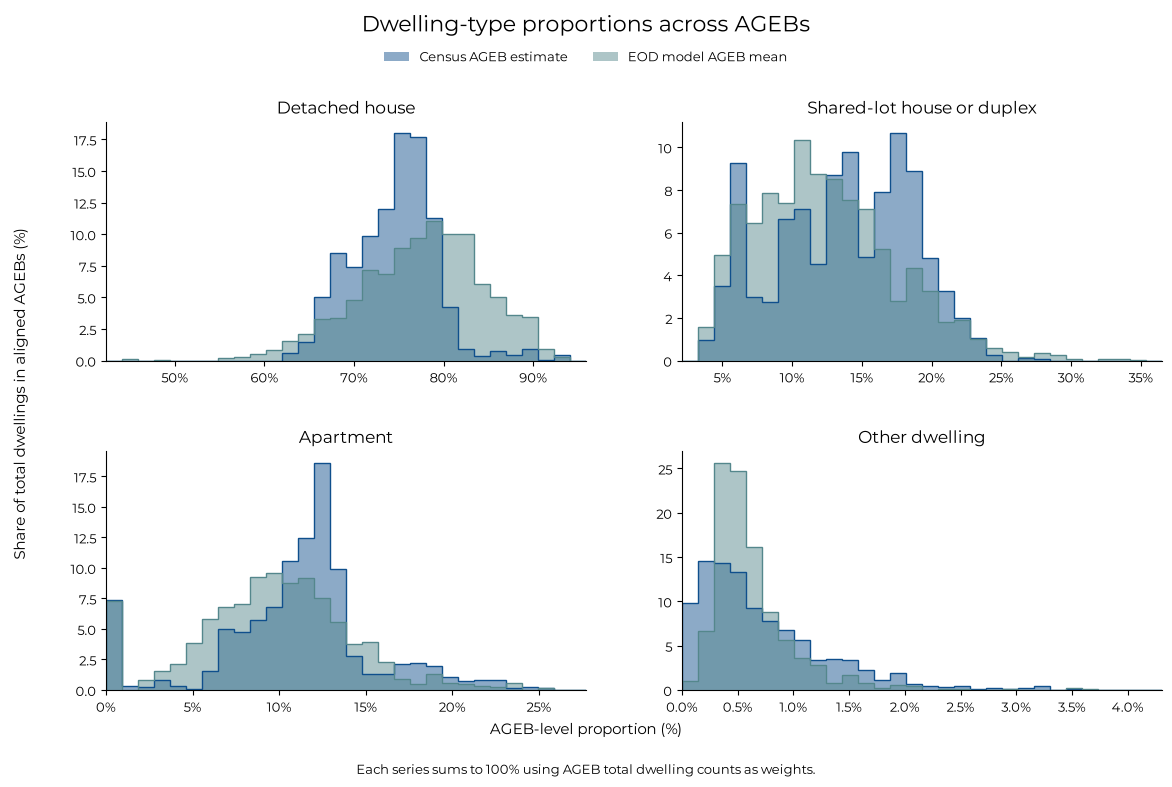

Saved the figure to `/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/dwelling_type/outputs/figures/distribuciones_proporciones_ageb_eod.png` and `/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/dwelling_type/outputs/figures/distribuciones_proporciones_ageb_eod.pdf`.

In [34]:
def sci_notation(value, decimals):
    """ Function to write values in scientific notation """
    mantissa, exponent = f"{value:.{decimals}e}".split("e")
    return rf"{mantissa} \times 10^{{{int(exponent)}}}" 

difference_table = rf"""
| | Casa única | Casa compartida/dúplex | Departamento | Otra vivienda |
|:---:|:---:|:---:|:---:|:---:|
| $D_k$ (percentage points) | ${weighted_mean_absolute_difference.loc["casa_unica"]*100:.2f}$ | ${weighted_mean_absolute_difference.loc["casa_compartida_duplex"]*100:.2f}$ | ${weighted_mean_absolute_difference.loc["departamento"]*100:.2f}$ | ${weighted_mean_absolute_difference.loc["otra_vivienda"]*100:.2f}$ |
"""

display(Markdown(difference_table))

font_paths = list((Path.home() / "Library/Fonts").glob("Montserrat*.ttf")) + list(Path("/Library/Fonts").glob("Montserrat*.ttf"))
for font_path in font_paths: fm.fontManager.addfont(str(font_path))

common_agebs = dwelling_level_distribution.index.intersection(ageb_level_distribution.index)
histogram_weights = ageb_level_distribution.loc[common_agebs, "total_viviendas"].to_numpy(dtype=float)
histogram_weights = 100 * histogram_weights / histogram_weights.sum()
category_labels = ["Detached house", "Shared-lot house or duplex", "Apartment", "Other dwelling"]
census_color = (0.06, 0.31, 0.55)
eod_color = (0.33, 0.53, 0.55)
png_path = Path("../outputs/figures/distribuciones_proporciones_ageb_eod.png")
pdf_path = Path("../outputs/figures/distribuciones_proporciones_ageb_eod.pdf")

with mpl.rc_context({"text.usetex": False, "font.family": "sans-serif", "font.sans-serif": ["Montserrat"]}):
    figure, axes = plt.subplots(2, 2, figsize=(12, 8))
    figure.patch.set_alpha(0)
    for ax, dwelling_type, category_label in zip(axes.flat, dwelling_types, category_labels):
        r_values = dwelling_level_distribution.loc[common_agebs, dwelling_type].to_numpy() * 100
        q_values = ageb_level_distribution.loc[common_agebs, dwelling_type].to_numpy() * 100
        minimum = min(r_values.min(), q_values.min())
        maximum = max(r_values.max(), q_values.max())
        margin = 0.04 * (maximum - minimum)
        bin_edges = np.linspace(max(0, minimum - margin), min(100, maximum + margin), 31)
        ax.hist(q_values, bins=bin_edges, weights=histogram_weights, color=census_color, alpha=0.48, label="Census AGEB estimate")
        ax.hist(r_values, bins=bin_edges, weights=histogram_weights, color=eod_color, alpha=0.48, label="EOD model AGEB mean")
        ax.hist(q_values, bins=bin_edges, weights=histogram_weights, histtype="step", color=census_color, linewidth=1)
        ax.hist(r_values, bins=bin_edges, weights=histogram_weights, histtype="step", color=eod_color, linewidth=1)
        ax.set_title(category_label, fontsize=12)
        ax.set_xlim(bin_edges[0], bin_edges[-1])
        ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=100, decimals=1 if dwelling_type == "otra_vivienda" else 0))
        ax.tick_params(axis="both", labelsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.patch.set_alpha(0)
    figure.suptitle("Dwelling-type proportions across AGEBs", fontsize=16, y=0.98)
    figure.supxlabel("AGEB-level proportion (%)", fontsize=11, y=0.07)
    figure.supylabel("Share of total dwellings in aligned AGEBs (%)", fontsize=11, x=0.02)
    figure.legend(*axes.flat[0].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(0.5, 0.945), ncol=2, frameon=False, fontsize=9)
    figure.subplots_adjust(left=0.1, right=0.98, bottom=0.13, top=0.84, hspace=0.38, wspace=0.2)
    figure.text(0.5, 0.025, "Each series sums to 100% using AGEB total dwelling counts as weights.", ha="center", fontsize=9)
    figure.savefig(png_path, dpi=600, bbox_inches="tight", transparent=True)
    figure.savefig(pdf_path, bbox_inches="tight", transparent=True)
    plt.show()

display(Markdown(f"Saved the figure to `{png_path.resolve()}` and `{pdf_path.resolve()}`."))

# Spatial calibration

In [35]:
def probability_calibration(original_data, gauge_data, categories):
    targets_by_ageb = gauge_data.set_index("ageb") if "ageb" in gauge_data.columns else gauge_data
    calibrated = np.zeros((len(original_data), len(categories)))
    ageb_groups = original_data.groupby("ageb", sort=False).indices
    progress = tqdm(ageb_groups.items(), total=len(ageb_groups), desc="Calibrating AGEBs", unit="AGEB")

    for ageb, positions in progress:
        original = original_data.iloc[positions][categories].to_numpy(dtype=float)
        weights = original_data.iloc[positions]["ponderador"].to_numpy(dtype=float)
        targets = targets_by_ageb.loc[ageb, categories].to_numpy(dtype=float)
        active = np.flatnonzero(targets > 0)
        baseline = active[np.argmax(targets[active])]
        active = np.r_[active[active != baseline], baseline]

        original_means = np.average(original[:, active], axis=0, weights=weights)
        if (original[:, active].sum(axis=1) == 0).any() or (original_means == 0).any():
            raise ValueError(f"AGEB {ageb}: no finite relative-entropy solution has the required probability support.")

        if len(active) == 1:
            calibrated[positions, active[0]] = 1.0
            continue

        log_original = np.full_like(original[:, active], -np.inf)
        np.log(original[:, active], out=log_original, where=original[:, active] > 0)
        normalized_weights = weights / weights.sum()
        initial_shifts = np.log(targets[active]) - np.log(original_means)
        initial_shifts = initial_shifts[:-1] - initial_shifts[-1]

        def moment_equations(shifts):
            log_scores = log_original + np.r_[shifts, 0.0]
            probabilities = np.exp(log_scores - logsumexp(log_scores, axis=1, keepdims=True))
            free_probabilities = probabilities[:, :-1]
            weighted_probabilities = free_probabilities * normalized_weights[:, None]
            residual = weighted_probabilities.sum(axis=0) - targets[active[:-1]]
            jacobian = np.diag(weighted_probabilities.sum(axis=0)) - free_probabilities.T @ weighted_probabilities
            return residual, jacobian

        solution = root(moment_equations, initial_shifts, jac=True, tol=1e-12)
        residual = moment_equations(solution.x)[0]
        if not np.allclose(residual, 0, atol=1e-10, rtol=0):
            raise ValueError(f"AGEB {ageb}: the target proportions cannot be matched.")

        progress.set_postfix(iterations=solution.nfev, max_error=f"{np.max(np.abs(residual)):.1e}")
        log_scores = log_original + np.r_[solution.x, 0.0]
        calibrated[np.ix_(positions, active)] = np.exp(log_scores - logsumexp(log_scores, axis=1, keepdims=True))

    result = original_data[["ageb", "folio_vivienda", "ponderador"]].copy()
    result[categories] = calibrated
    return result

In [36]:
calibrated_data = probability_calibration(
    original_data=dwelling_level_data,
    gauge_data=ageb_level_data,
    categories=dwelling_types
)

Calibrating AGEBs:   0%|          | 0/1046 [00:00<?, ?AGEB/s]

In [37]:
calibrated_level_distribution = calibrated_data[dwelling_types].mul(calibrated_data["ponderador"], axis=0).groupby(calibrated_data["ageb"]).sum().div(calibrated_data.groupby("ageb")["ponderador"].sum(), axis=0)
common_calibrated_agebs = calibrated_level_distribution.index.intersection(ageb_level_distribution.index)
ageb_weights = ageb_level_distribution.loc[common_calibrated_agebs, "total_viviendas"]
calibrated_mean_absolute_difference = calibrated_level_distribution.loc[common_calibrated_agebs, dwelling_types].sub(ageb_level_distribution.loc[common_calibrated_agebs, dwelling_types]).abs().mul(ageb_weights, axis=0).sum().div(ageb_weights.sum())


| | Detached house | Shared-lot house or duplex | Apartment | Other dwelling |
|:---:|:---:|:---:|:---:|:---:|
| Calibrated $D_k$ (percentage points) | $7.01 \times 10^{-15}$ | $2.24 \times 10^{-15}$ | $1.93 \times 10^{-15}$ | $2.27 \times 10^{-15}$ |


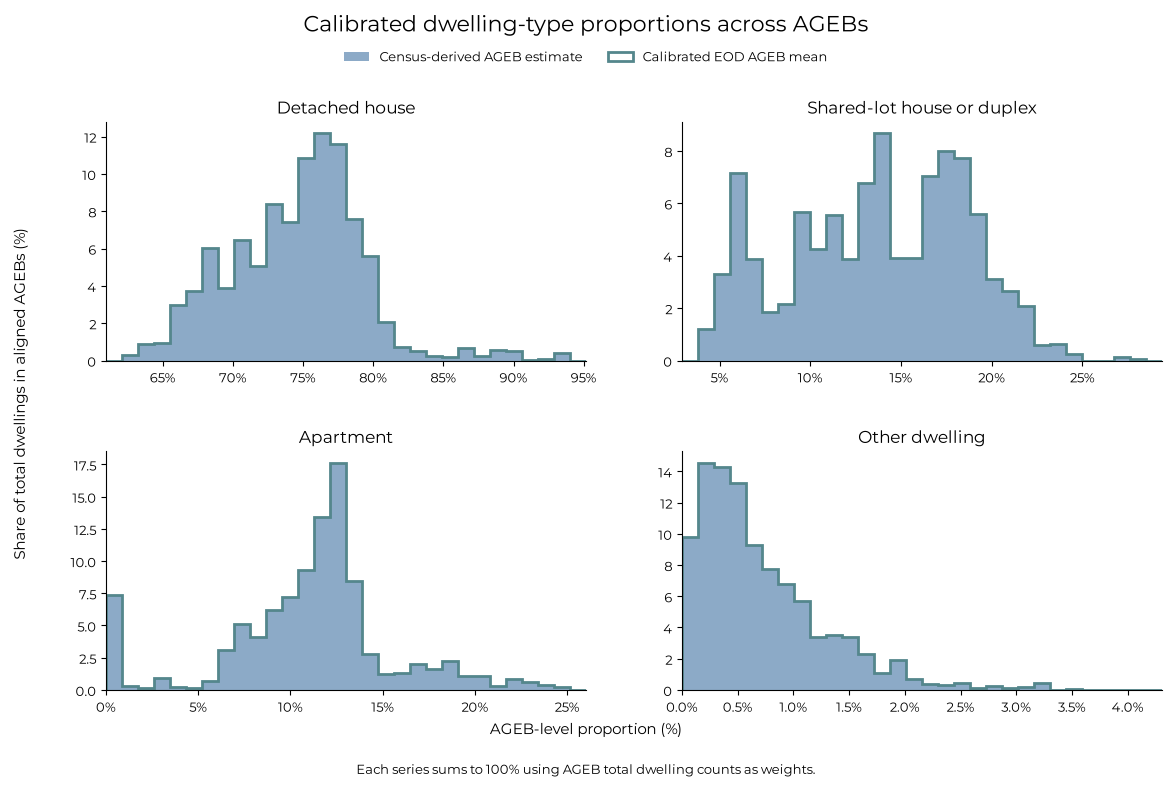

Saved the figure to `/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/dwelling_type/outputs/figures/distribuciones_proporciones_ageb_calibradas.png` and `/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/dwelling_type/outputs/figures/distribuciones_proporciones_ageb_calibradas.pdf`.

In [38]:
difference_table = rf"""
| | Detached house | Shared-lot house or duplex | Apartment | Other dwelling |
|:---:|:---:|:---:|:---:|:---:|
| Calibrated $D_k$ (percentage points) | ${sci_notation(calibrated_mean_absolute_difference.loc["casa_unica"]*100, 2)}$ | ${sci_notation(calibrated_mean_absolute_difference.loc["casa_compartida_duplex"]*100, 2)}$ | ${sci_notation(calibrated_mean_absolute_difference.loc["departamento"]*100, 2)}$ | ${sci_notation(calibrated_mean_absolute_difference.loc["otra_vivienda"]*100, 2)}$ |
"""
display(Markdown(difference_table))

font_paths = list((Path.home() / "Library/Fonts").glob("Montserrat*.ttf")) + list(Path("/Library/Fonts").glob("Montserrat*.ttf"))
for font_path in font_paths: fm.fontManager.addfont(str(font_path))

histogram_weights = ageb_weights.to_numpy(dtype=float)
histogram_weights = 100 * histogram_weights / histogram_weights.sum()
category_labels = ["Detached house", "Shared-lot house or duplex", "Apartment", "Other dwelling"]
census_color = (0.06, 0.31, 0.55)
eod_color = (0.33, 0.53, 0.55)
png_path = Path("../outputs/figures/distribuciones_proporciones_ageb_calibradas.png")
pdf_path = Path("../outputs/figures/distribuciones_proporciones_ageb_calibradas.pdf")

with mpl.rc_context({"text.usetex": False, "font.family": "sans-serif", "font.sans-serif": ["Montserrat"]}):
    figure, axes = plt.subplots(2, 2, figsize=(12, 8))
    figure.patch.set_alpha(0)

    for ax, dwelling_type, category_label in zip(axes.flat, dwelling_types, category_labels):
        calibrated_values = calibrated_level_distribution.loc[common_calibrated_agebs, dwelling_type].to_numpy() * 100
        q_values = ageb_level_distribution.loc[common_calibrated_agebs, dwelling_type].to_numpy() * 100
        minimum = min(calibrated_values.min(), q_values.min())
        maximum = max(calibrated_values.max(), q_values.max())
        margin = 0.04 * (maximum - minimum)
        bin_edges = np.linspace(max(0, minimum - margin), min(100, maximum + margin), 31)

        ax.hist(q_values, bins=bin_edges, weights=histogram_weights, color=census_color, alpha=0.48, label="Census-derived AGEB estimate")
        ax.hist(calibrated_values, bins=bin_edges, weights=histogram_weights, histtype="step", color=eod_color, linewidth=2, label="Calibrated EOD AGEB mean")
        ax.set_title(category_label, fontsize=12)
        ax.set_xlim(bin_edges[0], bin_edges[-1])
        ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=100, decimals=1 if dwelling_type == "otra_vivienda" else 0))
        ax.tick_params(axis="both", labelsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.patch.set_alpha(0)

    figure.suptitle("Calibrated dwelling-type proportions across AGEBs", fontsize=16, y=0.98)
    figure.supxlabel("AGEB-level proportion (%)", fontsize=11, y=0.07)
    figure.supylabel("Share of total dwellings in aligned AGEBs (%)", fontsize=11, x=0.02)
    figure.legend(*axes.flat[0].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(0.5, 0.945), ncol=2, frameon=False, fontsize=9)
    figure.subplots_adjust(left=0.1, right=0.98, bottom=0.13, top=0.84, hspace=0.38, wspace=0.2)
    figure.text(0.5, 0.025, "Each series sums to 100% using AGEB total dwelling counts as weights.", ha="center", fontsize=9)
    figure.savefig(png_path, dpi=600, bbox_inches="tight", transparent=True)
    figure.savefig(pdf_path, bbox_inches="tight", transparent=True)
    plt.show()

display(Markdown(f"Saved the figure to `{png_path.resolve()}` and `{pdf_path.resolve()}`."))

# Sampling

In [39]:
def categorical_sampling(dataframe):
    categories = ["casa_unica", "casa_compartida_duplex", "departamento", "otra_vivienda"]
    random_generator = np.random.default_rng(2026)
    result = dataframe.copy()
    result["categoria_muestreada"] = [random_generator.choice(categories, p=probabilities) for probabilities in result[categories].to_numpy()]
    return result

In [40]:
dwelling_calibrated_data = categorical_sampling(dataframe=calibrated_data)

# Results

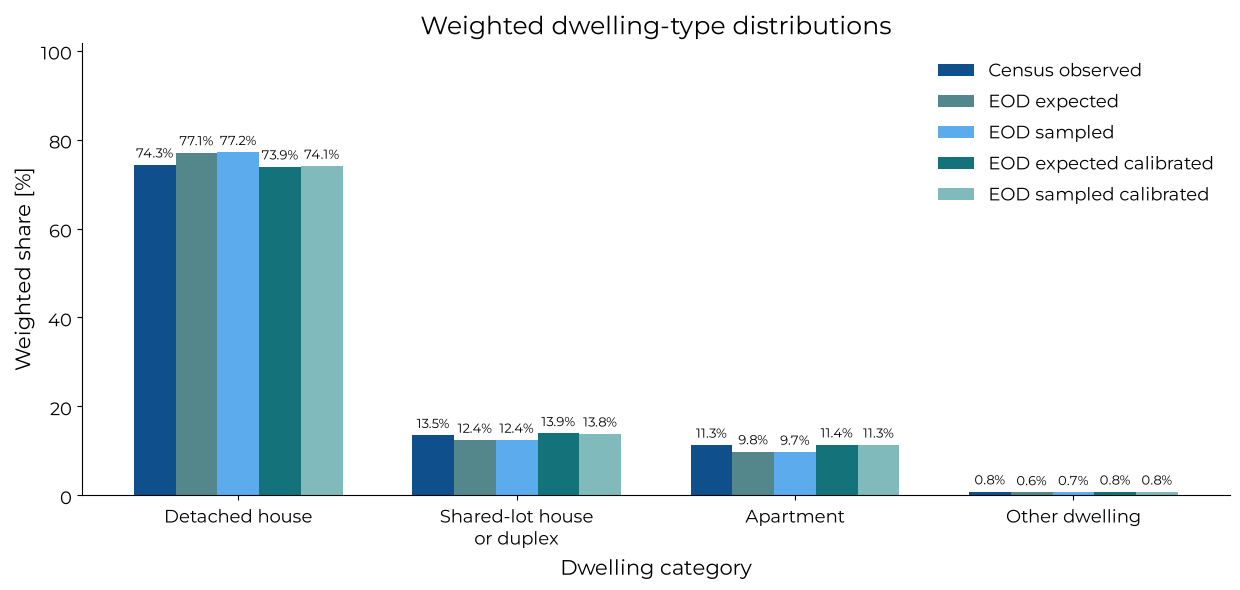

Saved PNG: `/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/dwelling_type/outputs/figures/distribucion_dwelling_type_censo_eod_calibrado.png`  
Saved PDF: `/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/dwelling_type/outputs/figures/distribucion_dwelling_type_censo_eod_calibrado.pdf`

In [41]:
census_data = pd.read_csv("../outputs/censo_viviendas_armonizado.csv", usecols=["dwelling_type", "factor_expansion"])
census_data = census_data.loc[census_data["dwelling_type"].notna()]

census_observed = np.array([census_data.loc[census_data["dwelling_type"].eq(category), "factor_expansion"].sum() / census_data["factor_expansion"].sum() for category in dwelling_types])
eod_expected = np.array([np.average(dwelling_level_data[category], weights=dwelling_level_data["ponderador"]) for category in dwelling_types])
eod_sampled = np.array([dwelling_level_data.loc[dwelling_level_data["muestreo_tipo_vivienda"].eq(category), "ponderador"].sum() / dwelling_level_data["ponderador"].sum() for category in dwelling_types])
eod_expected_calibrated = np.array([np.average(calibrated_data[category], weights=calibrated_data["ponderador"]) for category in dwelling_types])
eod_sampled_calibrated = np.array([dwelling_calibrated_data.loc[dwelling_calibrated_data["categoria_muestreada"].eq(category), "ponderador"].sum() / dwelling_calibrated_data["ponderador"].sum() for category in dwelling_types])

font_paths = list((Path.home() / "Library/Fonts").glob("Montserrat*.ttf")) + list(Path("/Library/Fonts").glob("Montserrat*.ttf"))
for font_path in font_paths: fm.fontManager.addfont(str(font_path))

series_colors = [(0.06, 0.31, 0.55), (0.33, 0.53, 0.55), (0.36, 0.67, 0.93), (0.08, 0.45, 0.48), (0.50, 0.73, 0.73)]
category_labels = ["Detached house", "Shared-lot house\nor duplex", "Apartment", "Other dwelling"]
series_labels = ["Census observed", "EOD expected", "EOD sampled", "EOD expected calibrated", "EOD sampled calibrated"]
plot_values = np.column_stack([census_observed, eod_expected, eod_sampled, eod_expected_calibrated, eod_sampled_calibrated]) * 100

figure_dir = Path("../outputs/figures")
figure_dir.mkdir(parents=True, exist_ok=True)
png_path = figure_dir / "distribucion_dwelling_type_censo_eod_calibrado.png"
pdf_path = figure_dir / "distribucion_dwelling_type_censo_eod_calibrado.pdf"

with mpl.rc_context({"text.usetex": False, "font.family": "sans-serif", "font.sans-serif": ["Montserrat"]}):
    fig, ax = plt.subplots(figsize=(12.5, 6))
    positions = np.arange(len(dwelling_types))
    bar_width = 0.15

    for series_index, (series_label, color) in enumerate(zip(series_labels, series_colors)):
        bars = ax.bar(positions + (series_index - 2) * bar_width, plot_values[:, series_index], width=bar_width, color=color, label=series_label)
        ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)

    ax.set_title("Weighted dwelling-type distributions", fontsize=18)
    ax.set_xlabel("Dwelling category", fontsize=15)
    ax.set_ylabel("Weighted share [%]", fontsize=15)
    ax.set_xticks(positions)
    ax.set_xticklabels(category_labels)
    ax.tick_params(axis="x", rotation=0, labelsize=13)
    ax.tick_params(axis="y", labelsize=13)
    ax.set_ylim(0, plot_values.max() * 1.32)
    ax.legend(frameon=False, fontsize=13, ncol=1, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    fig.savefig(png_path, dpi=600, bbox_inches="tight", transparent=True)
    fig.savefig(pdf_path, bbox_inches="tight", transparent=True)
    plt.show()

display(Markdown(f"Saved PNG: `{png_path.resolve()}`  \nSaved PDF: `{pdf_path.resolve()}`"))

In [42]:
# Clean output and export
dwelling_calibrated_data.insert(dwelling_calibrated_data.columns.get_loc("categoria_muestreada") - 1, "probabilidades_tipo_vivienda_calibradas", dwelling_calibrated_data[['casa_unica', 'casa_compartida_duplex', 'departamento', 'otra_vivienda']].to_dict("records"))
dwelling_calibrated_data.drop(columns=['casa_unica', 'casa_compartida_duplex', 'departamento', 'otra_vivienda'], inplace=True)
dwelling_calibrated_data.rename(columns={"categoria_muestreada": "muestreo_tipo_vivienda_calibrado"}, inplace=True)
dwelling_calibrated_data = dwelling_calibrated_data.merge(eod_data[["folio_vivienda", "ponderador", "ageb", "probabilidad_tipo_vivienda", "muestreo_tipo_vivienda"]], on=["folio_vivienda", "ponderador", "ageb"], how="left")
for column in ["probabilidad_tipo_vivienda", "muestreo_tipo_vivienda"]:
    dwelling_calibrated_data.insert(dwelling_calibrated_data.columns.get_loc("probabilidades_tipo_vivienda_calibradas"), column, dwelling_calibrated_data.pop(column))
dwelling_calibrated_data.rename(columns={"probabilidad_tipo_vivienda":"probabilidades_tipo_vivienda_iniciales","muestreo_tipo_vivienda": "muestreo_tipo_vivienda_inicial"}, inplace=True)
dwelling_calibrated_data.to_csv(outputs_path / "eod_tipo_vivienda_calibrado.csv", index=False)
preview = dwelling_calibrated_data.head(3).copy()
preview["probabilidades_tipo_vivienda_iniciales"] = preview["probabilidades_tipo_vivienda_iniciales"].map(json.loads)
display(Markdown(f"### eod_tipo_vivienda_calibrado.csv\n\n**Rows:** {len(dwelling_calibrated_data):,} | **Columns:** {len(dwelling_calibrated_data.columns):,}\n\n{preview.to_markdown(index=False)}"))

### eod_tipo_vivienda_calibrado.csv

**Rows:** 17,901 | **Columns:** 7

| ageb          |   folio_vivienda |   ponderador | probabilidades_tipo_vivienda_iniciales                                                                                                                         | muestreo_tipo_vivienda_inicial   | probabilidades_tipo_vivienda_calibradas                                                                                                                           | muestreo_tipo_vivienda_calibrado   |
|:--------------|-----------------:|-------------:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------|:---------------------------------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------|
| 1409700251418 |                1 |           51 | {'casa_unica': 0.9488597199817904, 'casa_compartida_duplex': 0.03291479251549034, 'departamento': 0.01718205735851752, 'otra_vivienda': 0.0010434301442017718} | casa_unica                       | {'casa_unica': 0.9483452225304642, 'casa_compartida_duplex': 0.027890156055534288, 'departamento': 0.023543165012050914, 'otra_vivienda': 0.00022145640195062226} | casa_unica                         |
| 140390001418A |               10 |          249 | {'casa_unica': 0.526180086586011, 'casa_compartida_duplex': 0.23224967030408128, 'departamento': 0.2360535759174426, 'otra_vivienda': 0.0055166671924651595}   | casa_compartida_duplex           | {'casa_unica': 0.3672301167659001, 'casa_compartida_duplex': 0.2607082525781788, 'departamento': 0.3657235600772999, 'otra_vivienda': 0.006338070578621175}       | departamento                       |
| 1403900010539 |              100 |          249 | {'casa_unica': 0.3843942824668903, 'casa_compartida_duplex': 0.3551772033491632, 'departamento': 0.18608247068569697, 'otra_vivienda': 0.07434604349824968}    | casa_compartida_duplex           | {'casa_unica': 0.3020786103922258, 'casa_compartida_duplex': 0.37151512410138465, 'departamento': 0.25164279952961366, 'otra_vivienda': 0.07476346597677588}      | casa_compartida_duplex             |